In [1]:
"""
<prompt>
  <task>
    알고리즘 4개를 활용해서 어떤 알고리즘이 가장 높은 f1 스코어를 가지는지 비교해서 최종 분석보고에 담아줘.
  </task>
</prompt>
"""

'\n<prompt>\n  <task>\n    알고리즘 4개를 활용해서 어떤 알고리즘이 가장 높은 f1 스코어를 가지는지 비교해서 최종 분석보고에 담아줘.\n  </task>\n</prompt>\n'

# 공공 민원 긴급처리 예측 모델
## 알고리즘 4종 비교 분석

| 항목 | 내용 |
|------|------|
| **목적** | 새 민원이 접수될 때 긴급처리가 필요한지 자동 판단 |
| **타깃** | 긴급처리여부 (긴급·높음 = 1, 보통·낮음 = 0) |
| **알고리즘** | 로지스틱회귀 · 의사결정트리 · 랜덤포레스트 · 그래디언트부스팅 |
| **비교 기준** | F1 스코어 (weighted) |

---
## 0. 라이브러리 임포트

In [2]:
# ─────────────────────────────────────────────────────────
# [개념] import = 미리 만들어진 머신러닝 도구를 꺼내 오는 명령
#   sklearn  : 파이썬 대표 머신러닝 라이브러리
#   pandas   : tables(데이터프레임)를 다루는 도구
#   matplotlib/seaborn : 차트 그리기 도구
# ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import platform, subprocess, warnings
warnings.filterwarnings('ignore')

# 4가지 분류 알고리즘
from sklearn.linear_model  import LogisticRegression          # 로지스틱회귀
from sklearn.tree          import DecisionTreeClassifier       # 의사결정트리
from sklearn.ensemble      import RandomForestClassifier       # 랜덤포레스트
from sklearn.ensemble      import GradientBoostingClassifier   # 그래디언트부스팅

# 데이터 준비 및 평가 도구
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import (f1_score, classification_report,
                                     confusion_matrix, roc_auc_score, roc_curve)

# 한글 폰트 설정 (OS별 자동 선택)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    r = subprocess.run(['fc-list', ':lang=ko'], capture_output=True, text=True)
    fonts = [l.split(':')[0].strip() for l in r.stdout.strip().split('\n') if l]
    if fonts:
        plt.rcParams['font.family'] = fm.FontProperties(fname=fonts[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


---
## 1. 데이터 로드 및 탐색

In [3]:
# ─────────────────────────────────────────────────────────
# [개념] 파일을 읽어 '데이터프레임(df)'으로 변환
#   → 데이터프레임 = 엑셀 표처럼 행(row)과 열(column)로 구성된 데이터 구조
# ─────────────────────────────────────────────────────────
FILE_PATH = 'input/public_sector_analysis_dataset_3000x20.xlsx'  # 실제 경로로 수정

df = pd.read_excel(FILE_PATH)
print(f'데이터 크기: {df.shape[0]}행 × {df.shape[1]}열')
df.head()

데이터 크기: 3000행 × 20열


,접수ID,접수일자,기관유형,기관명,지역,서비스분야,민원채널,신청자연령대,취약계층여부,긴급도,민원복잡도,담당인력수,첨부서류수,예산관련금액_만원,처리기준일수,실제처리일수,재문의횟수,만족도점수,지연여부,행정비용추정_만원
0,PUB2025-0001,2025-01-01,교육청,가상서울교육청,수도권,교육,방문,40대,0,낮음,2,3,3,366,9,7,0,4.9,0,28.7
1,PUB2025-0002,2025-01-01,기초지자체,가상청주시청,충청권,복지,온라인,50대,0,낮음,2,2,3,0,12,11,2,5.0,0,42.1
2,PUB2025-0003,2025-01-01,중앙행정기관,가상환경부,전국,보건의료,방문,30대,0,낮음,2,3,1,1105,9,10,4,3.2,1,48.7
3,PUB2025-0004,2025-01-01,중앙행정기관,가상환경부,전국,복지,모바일앱,40대,0,보통,5,5,7,0,10,13,3,3.2,1,71.1
4,PUB2025-0005,2025-01-01,공공기관,가상보건산업진흥원,전국,일자리,모바일앱,50대,0,보통,3,4,4,0,10,8,0,4.7,0,46.1


긴급도 분포:
긴급도
보통    1658
높음     586
낮음     550
긴급     206
Name: count, dtype: int64


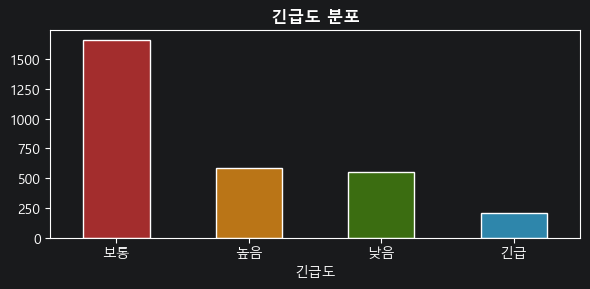

In [4]:
# 긴급도 분포 확인 — 클래스 불균형 파악
print('긴급도 분포:')
print(df['긴급도'].value_counts())
df['긴급도'].value_counts().plot(kind='bar', color=['#A32D2D','#BA7517','#3B6D11','#2E86AB'],
                                  edgecolor='white', figsize=(6,3))
plt.title('긴급도 분포', fontweight='bold')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---
## 2. 전처리 — 피처 엔지니어링

In [5]:
# ─────────────────────────────────────────────────────────
# [개념] 날짜에서 '월'과 '분기'를 추출 = 파생 변수(Feature Engineering)
#   → 모델은 날짜 텍스트를 직접 이해 못함
#     숫자(1월=1, 2월=2 …)로 변환해서 패턴을 학습하게 함
# ─────────────────────────────────────────────────────────
df['접수월']   = df['접수일자'].dt.month    # 1~12
df['접수분기'] = df['접수일자'].dt.quarter  # 1~4

# ─────────────────────────────────────────────────────────
# [개념] LabelEncoder = 문자(범주)를 숫자로 바꾸는 도구
#   예) 기관유형: '교육청'→0, '공공기관'→1, '광역지자체'→2 …
#   → 컴퓨터는 숫자만 계산할 수 있으므로 반드시 필요한 과정
# ─────────────────────────────────────────────────────────
cat_cols = ['기관유형', '지역', '서비스분야', '민원채널', '신청자연령대', '긴급도']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])  # 원본 유지 + 숫자 버전 추가
    le_dict[col] = le                              # 나중에 역변환 시 사용
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

기관유형: {'공공기관': np.int64(0), '광역지자체': np.int64(1), '교육청': np.int64(2), '기초지자체': np.int64(3), '중앙행정기관': np.int64(4)}
지역: {'수도권': np.int64(0), '영남권': np.int64(1), '전국': np.int64(2), '충청권': np.int64(3), '호남권': np.int64(4)}
서비스분야: {'교육': np.int64(0), '교통': np.int64(1), '문화관광': np.int64(2), '보건의료': np.int64(3), '복지': np.int64(4), '세무': np.int64(5), '안전': np.int64(6), '일자리': np.int64(7), '주거': np.int64(8), '환경': np.int64(9)}
민원채널: {'모바일앱': np.int64(0), '방문': np.int64(1), '온라인': np.int64(2), '우편': np.int64(3), '전화': np.int64(4)}
신청자연령대: {'20대 이하': np.int64(0), '30대': np.int64(1), '40대': np.int64(2), '50대': np.int64(3), '60대 이상': np.int64(4)}
긴급도: {'긴급': np.int64(0), '낮음': np.int64(1), '높음': np.int64(2), '보통': np.int64(3)}


In [6]:
# ─────────────────────────────────────────────────────────
# [개념] 타깃 변수(y) 정의 — '무엇을 맞힐 것인가?'
#   4단계 긴급도를 이진(Binary)으로 단순화:
#     긴급 + 높음  → 1 (빠른 처리 필요)
#     보통 + 낮음  → 0 (일반 처리 가능)
#   이진 분류가 모델 학습·해석 모두 훨씬 명확함
# ─────────────────────────────────────────────────────────
df['긴급처리여부'] = df['긴급도'].isin(['긴급', '높음']).astype(int)

print('긴급처리여부 분포:')
print(df['긴급처리여부'].value_counts())
print(f'\n긴급처리 비율: {df["긴급처리여부"].mean():.1%}')

긴급처리여부 분포:
긴급처리여부
0    2208
1     792
Name: count, dtype: int64

긴급처리 비율: 26.4%


In [7]:
# ─────────────────────────────────────────────────────────
# [개념] 피처(Feature) 선택 — '어떤 정보를 힌트로 줄 것인가?'
#   ⚠ 중요: 접수 시점에 '아직 알 수 없는' 정보는 절대 포함 금지
#     제외 항목:
#       처리기준일수 — 긴급도가 결정돼야 알 수 있는 값 (데이터 누설)
#       실제처리일수 — 처리가 완료돼야 알 수 있는 결과값
#       지연여부     — 마찬가지로 사후 정보
# ─────────────────────────────────────────────────────────
FEATURES = [
    '민원복잡도',       # 민원의 복잡한 정도 (1~5)
    '첨부서류수',       # 제출 서류 수
    '취약계층여부',     # 취약계층 신청 여부 (0/1)
    '재문의횟수',       # 이전 문의 횟수
    '예산관련금액_만원', # 관련 예산 규모
    '담당인력수',       # 배정된 담당자 수
    '접수월',           # 파생 변수: 접수 월
    '접수분기',         # 파생 변수: 접수 분기
    '기관유형_enc',     # 인코딩된 범주형 피처들
    '지역_enc',
    '서비스분야_enc',
    '민원채널_enc',
    '신청자연령대_enc',
]

X = df[FEATURES]   # 입력: 모델이 보는 정보
y = df['긴급처리여부']  # 정답: 모델이 맞혀야 할 값
print(f'입력 피처 수: {len(FEATURES)}개  |  전체 샘플 수: {len(X)}개')

입력 피처 수: 13개  |  전체 샘플 수: 3000개


---
## 3. 데이터 분할 및 스케일링

In [8]:
# ─────────────────────────────────────────────────────────
# [개념] train_test_split = 데이터를 훈련용/테스트용으로 나누기
#   test_size=0.2  → 전체의 20%를 시험지로 봉인
#   stratify=y     → 긴급/일반 비율을 분할 후에도 동일하게 유지
#   random_state   → 같은 숫자면 누가 실행해도 동일한 분할 결과 보장
#
#   비유: 전체 1000개 예제 문제 중 800개로 공부(Train),
#         나머지 200개로 실제 시험(Test)
# ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습 데이터: {X_train.shape[0]}건  |  테스트 데이터: {X_test.shape[0]}건')
print(f'긴급처리 비율 — 학습: {y_train.mean():.1%}  |  테스트: {y_test.mean():.1%}')

학습 데이터: 2400건  |  테스트 데이터: 600건
긴급처리 비율 — 학습: 26.4%  |  테스트: 26.3%


In [9]:
# ─────────────────────────────────────────────────────────
# [개념] StandardScaler = 피처 값의 크기를 통일하는 정규화
#   예) 예산금액(0~9000만원) vs 복잡도(1~5) → 크기 차이가 너무 큼
#   → 로지스틱회귀처럼 거리 기반 모델은 크기가 큰 피처에 편향됨
#   → 평균=0, 표준편차=1 기준으로 모든 피처를 동일 스케일로 변환
#
#   ⚠ fit은 학습 데이터로만! 테스트에는 transform만 적용
#      (테스트 데이터 정보가 학습에 유입되면 '데이터 누설')
# ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # 학습 + 변환
X_test_sc  = scaler.transform(X_test)       # 변환만 (학습 데이터 기준 적용)
print('✅ 스케일링 완료')

✅ 스케일링 완료


---
## 4. 알고리즘 4종 학습 및 비교

In [10]:
# ─────────────────────────────────────────────────────────
# [개념] 각 알고리즘의 핵심 원리:
#
#  ① 로지스틱회귀 (Logistic Regression)
#     → 피처들의 가중합으로 확률을 계산하는 가장 단순한 선형 모델
#     → 해석이 쉽지만 복잡한 비선형 패턴은 포착하기 어려움
#
#  ② 의사결정트리 (Decision Tree)
#     → "예산이 500만원 이상이면서 복잡도가 4 이상이면 긴급" 같은
#        규칙(if-else)을 트리 구조로 자동 학습
#     → 해석 직관적, 과적합 위험 있음
#
#  ③ 랜덤포레스트 (Random Forest)
#     → 수백 개의 의사결정트리를 무작위로 만들고 다수결로 예측
#     → 단일 트리보다 안정적, 과적합 억제
#
#  ④ 그래디언트부스팅 (Gradient Boosting)
#     → 이전 모델의 오답에 집중해 다음 모델을 순차적으로 보완
#     → 4가지 중 일반적으로 가장 높은 성능
# ─────────────────────────────────────────────────────────
models = {
    '로지스틱회귀':     LogisticRegression(max_iter=1000, random_state=42),
    '의사결정트리':     DecisionTreeClassifier(max_depth=6, random_state=42),
    '랜덤포레스트':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    '그래디언트부스팅': GradientBoostingClassifier(n_estimators=100, random_state=42),
    #  n_estimators=100 → 트리(약한 모델)를 100개 사용
    #  random_state=42  → 재현성 보장 (어떤 값이든 동일하게 유지하면 OK)
}

In [11]:
# ─────────────────────────────────────────────────────────
# [개념] 핵심 3단계:
#   1) model.fit(X_train, y_train)   → 학습: 훈련 데이터로 패턴 학습
#   2) model.predict(X_test)         → 예측: 새 데이터 보고 0/1 판단
#   3) f1_score(y_test, pred)        → 평가: 정답과 예측 비교
#
# [개념] F1 스코어란?
#   Precision(정밀도): 긴급이라 예측한 것 중 실제 긴급 비율
#   Recall(재현율):    실제 긴급인 것 중 긴급이라 잡아낸 비율
#   F1 = 둘의 조화평균 → 0에 가까울수록 나쁨, 1에 가까울수록 좋음
#
# [개념] CV(교차검증, Cross Validation)란?
#   학습 데이터를 5등분 → 4개로 학습, 1개로 검증을 5회 반복
#   → 운 좋은 분할에 편향되지 않은 진짜 실력 측정
# ─────────────────────────────────────────────────────────

results = {}
print(f'{"모델":<16} {"F1(weighted)":>12} {"F1(긴급)":>10} {"AUC":>8} {"CV-F1":>8} {"Acc":>8}')
print('─' * 65)

for name, model in models.items():
    # 로지스틱회귀만 스케일링된 데이터 사용 (거리 기반 모델)
    Xtr = X_train_sc if name == '로지스틱회귀' else X_train
    Xte = X_test_sc  if name == '로지스틱회귀' else X_test

    model.fit(Xtr, y_train)          # ① 학습
    pred = model.predict(Xte)        # ② 예측 (0 또는 1)
    prob = model.predict_proba(Xte)[:, 1]  # 긴급처리 확률값 (ROC용)

    f1_w  = f1_score(y_test, pred, average='weighted')  # 전체 F1
    f1_ug = f1_score(y_test, pred, pos_label=1)          # 긴급 클래스 F1
    acc   = (pred == y_test).mean()                       # 정확도
    auc   = roc_auc_score(y_test, prob)                   # AUC
    cv    = cross_val_score(model, Xtr, y_train,
                            cv=5, scoring='f1_weighted').mean()  # 교차검증
    cm    = confusion_matrix(y_test, pred)                # 혼동 행렬

    results[name] = dict(model=model, pred=pred, prob=prob,
                         f1_w=f1_w, f1_ug=f1_ug, acc=acc, auc=auc, cv=cv, cm=cm)
    print(f'{name:<16} {f1_w:>12.4f} {f1_ug:>10.4f} {auc:>8.4f} {cv:>8.4f} {acc:>8.4f}')

best = max(results, key=lambda k: results[k]['f1_w'])
print(f'\n🏆 최우수 모델: {best}  (F1={results[best]["f1_w"]:.4f})')

모델               F1(weighted)     F1(긴급)      AUC    CV-F1      Acc
─────────────────────────────────────────────────────────────────
로지스틱회귀                 0.6250     0.0000   0.5374   0.6239   0.7367
의사결정트리                 0.6378     0.0870   0.4370   0.6280   0.7200
랜덤포레스트                 0.6278     0.0351   0.5032   0.6271   0.7250
그래디언트부스팅               0.6302     0.0245   0.4778   0.6226   0.7350

🏆 최우수 모델: 의사결정트리  (F1=0.6378)


In [12]:
# 최우수 모델 상세 리포트
print(f'=== {best} — 상세 분류 보고서 ===')
print(classification_report(y_test, results[best]['pred'],
                             target_names=['일반처리(0)', '긴급처리(1)']))

=== 의사결정트리 — 상세 분류 보고서 ===
              precision    recall  f1-score   support

     일반처리(0)       0.74      0.96      0.83       442
     긴급처리(1)       0.31      0.05      0.09       158

    accuracy                           0.72       600
   macro avg       0.52      0.50      0.46       600
weighted avg       0.63      0.72      0.64       600



---
## 5. 최종 분석 보고서 시각화

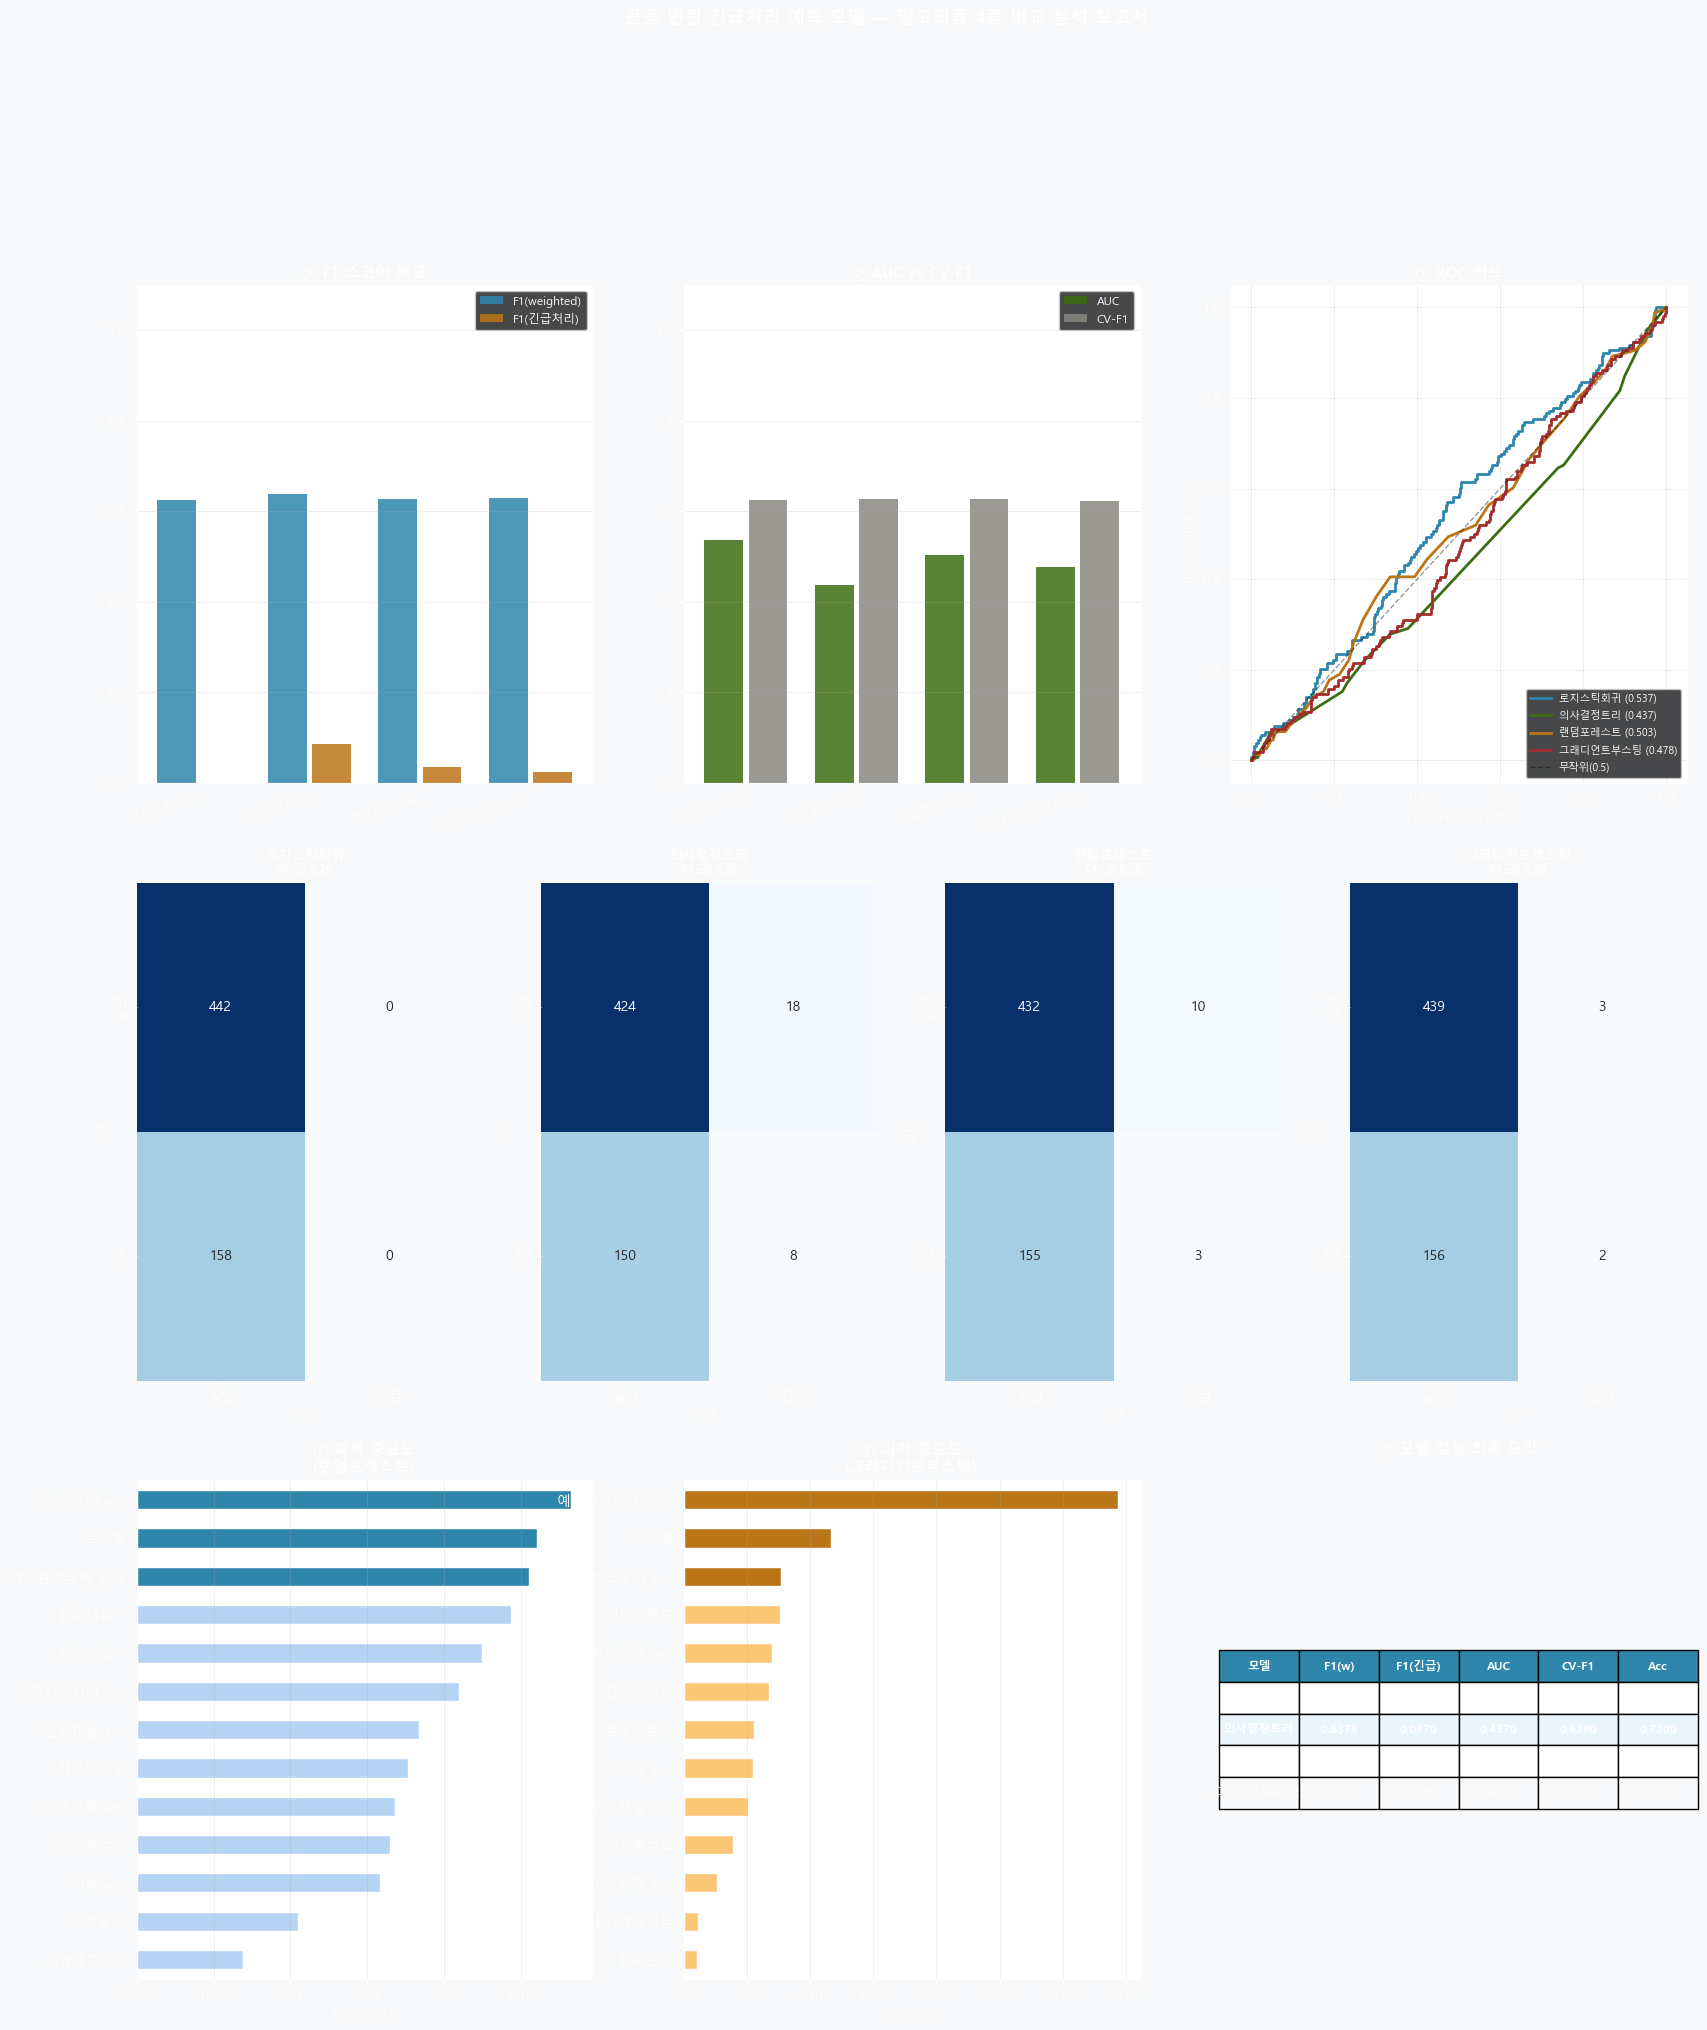

✅ 보고서 저장 완료: urgency_model_report.png


In [13]:
# ─────────────────────────────────────────────────────────
# [개념] 시각화의 각 차트가 보여주는 것:
#   ① F1 막대     → 4개 모델의 전체/긴급 F1 직접 비교
#   ② AUC/CV 막대 → 확률 구분력(AUC)과 일반화 성능(CV) 비교
#   ③ ROC 커브    → 임계값 변화에 따른 민감도-특이도 트레이드오프
#   ④ 혼동 행렬   → 실제 vs 예측 교차표 (어떤 오류를 얼마나 범하는지)
#   ⑤ 피처 중요도 → 어떤 정보가 판단에 가장 큰 영향을 미치는지
# ─────────────────────────────────────────────────────────

NAMES   = list(results.keys())
PALETTE = ['#2E86AB', '#3B6D11', '#BA7517', '#A32D2D']
C_BLUE  = '#2E86AB'; C_GREEN = '#3B6D11'; C_ORANGE = '#BA7517'

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#F8F9FA')
x = np.arange(len(NAMES))

# ── ① F1 스코어 비교 ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
f1_ws  = [results[n]['f1_w']  for n in NAMES]
f1_ugs = [results[n]['f1_ug'] for n in NAMES]
ax1.bar(x-0.2, f1_ws,  0.35, label='F1(weighted)', color=C_BLUE,   alpha=0.85)
ax1.bar(x+0.2, f1_ugs, 0.35, label='F1(긴급처리)', color=C_ORANGE, alpha=0.85)
for i,(fw,fu) in enumerate(zip(f1_ws,f1_ugs)):
    ax1.text(i-0.2, fw+0.01, f'{fw:.3f}', ha='center', va='bottom', fontsize=8)
    ax1.text(i+0.2, fu+0.01, f'{fu:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(NAMES, rotation=18, ha='right', fontsize=8.5)
ax1.set_ylim(0, 1.1); ax1.set_title('① F1 스코어 비교', fontweight='bold', fontsize=11)
ax1.legend(fontsize=8.5); ax1.set_facecolor('#FFFFFF'); ax1.grid(axis='y', alpha=0.3)

# ── ② AUC vs CV-F1 ──────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
aucs = [results[n]['auc'] for n in NAMES]
cvs  = [results[n]['cv']  for n in NAMES]
ax2.bar(x-0.2, aucs, 0.35, label='AUC',   color=C_GREEN,   alpha=0.85)
ax2.bar(x+0.2, cvs,  0.35, label='CV-F1', color='#888780', alpha=0.85)
for i,(a,c) in enumerate(zip(aucs,cvs)):
    ax2.text(i-0.2, a+0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
    ax2.text(i+0.2, c+0.01, f'{c:.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(NAMES, rotation=18, ha='right', fontsize=8.5)
ax2.set_ylim(0, 1.1); ax2.set_title('② AUC vs CV-F1', fontweight='bold', fontsize=11)
ax2.legend(fontsize=8.5); ax2.set_facecolor('#FFFFFF'); ax2.grid(axis='y', alpha=0.3)

# ── ③ ROC 커브 ──────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
for i, name in enumerate(NAMES):
    fpr, tpr, _ = roc_curve(y_test, results[name]['prob'])
    ax3.plot(fpr, tpr, color=PALETTE[i], lw=2,
             label=f"{name} ({results[name]['auc']:.3f})")
ax3.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='무작위(0.5)')
ax3.set_xlabel('False Positive Rate', fontsize=9)
ax3.set_ylabel('True Positive Rate',  fontsize=9)
ax3.set_title('③ ROC 커브', fontweight='bold', fontsize=11)
ax3.legend(fontsize=7.5, loc='lower right')
ax3.grid(alpha=0.3); ax3.set_facecolor('#FFFFFF')

# ── ④ 혼동 행렬 (4개) ───────────────────────────────────
for idx, name in enumerate(NAMES):
    ax = fig.add_subplot(3, 4, 5 + idx)
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['일반','긴급'], yticklabels=['일반','긴급'], cbar=False)
    ax.set_title(f'{name}\nF1={results[name]["f1_w"]:.3f}', fontweight='bold', fontsize=9.5)
    ax.set_ylabel('실제', fontsize=8); ax.set_xlabel('예측', fontsize=8)

# ── ⑤ 피처 중요도 (랜덤포레스트) ────────────────────────
ax8 = fig.add_subplot(3, 3, 7)
fi_rf = pd.Series(results['랜덤포레스트']['model'].feature_importances_,
                  index=FEATURES).sort_values(ascending=True)
clr8 = ['#B5D4F4' if i < len(fi_rf)-3 else C_BLUE for i in range(len(fi_rf))]
fi_rf.plot(kind='barh', ax=ax8, color=clr8, edgecolor='white')
ax8.set_title('⑤ 피처 중요도\n(랜덤포레스트)', fontweight='bold', fontsize=11)
ax8.set_xlabel('Importance', fontsize=9)
ax8.set_facecolor('#FFFFFF'); ax8.grid(axis='x', alpha=0.3)

# ── ⑥ 피처 중요도 (그래디언트부스팅) ────────────────────
ax9 = fig.add_subplot(3, 3, 8)
fi_gb = pd.Series(results['그래디언트부스팅']['model'].feature_importances_,
                  index=FEATURES).sort_values(ascending=True)
clr9 = ['#FAC775' if i < len(fi_gb)-3 else C_ORANGE for i in range(len(fi_gb))]
fi_gb.plot(kind='barh', ax=ax9, color=clr9, edgecolor='white')
ax9.set_title('⑥ 피처 중요도\n(그래디언트부스팅)', fontweight='bold', fontsize=11)
ax9.set_xlabel('Importance', fontsize=9)
ax9.set_facecolor('#FFFFFF'); ax9.grid(axis='x', alpha=0.3)

# ── ⑦ 성능 요약 테이블 ──────────────────────────────────
ax10 = fig.add_subplot(3, 3, 9)
ax10.axis('off')
best_idx = NAMES.index(best)
rows = [[n, f"{results[n]['f1_w']:.4f}", f"{results[n]['f1_ug']:.4f}",
         f"{results[n]['auc']:.4f}", f"{results[n]['cv']:.4f}",
         f"{results[n]['acc']:.4f}"] for n in NAMES]
tab = ax10.table(cellText=rows,
    colLabels=['모델','F1(w)','F1(긴급)','AUC','CV-F1','Acc'],
    loc='center', cellLoc='center')
tab.auto_set_font_size(False); tab.set_fontsize(8.5); tab.scale(1.05, 1.9)
for (r, c), cell in tab.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2E86AB'); cell.set_text_props(color='white', fontweight='bold')
    elif r-1 == best_idx:
        cell.set_facecolor('#EAF4FB'); cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F8F9FA')
ax10.set_title('⑦ 모델 성능 최종 요약', fontweight='bold', fontsize=11, pad=20)

plt.suptitle('공공 민원 긴급처리 예측 모델 — 알고리즘 4종 비교 분석 보고서',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(pad=2.5)
plt.savefig('urgency_model_report.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print('✅ 보고서 저장 완료: urgency_model_report.png')

---
## 6. 신규 민원 긴급도 예측 (실전 활용)

In [14]:
# ─────────────────────────────────────────────────────────
# [개념] 학습된 모델로 '새로운 민원'의 긴급도를 실시간 예측
#   → 접수 창구에서 입력값만 넣으면 즉시 우선순위 결정 가능
#
# ※ best_model = 위에서 F1 스코어가 가장 높았던 모델 자동 선택
# ─────────────────────────────────────────────────────────
best_model = results[best]['model']

# 새 민원 예시 (접수 시점에 알 수 있는 정보만 입력)
new_complaint = pd.DataFrame([{
    '민원복잡도':        4,      # 꽤 복잡한 민원
    '첨부서류수':        5,      # 서류 5개 첨부
    '취약계층여부':      1,      # 취약계층 신청
    '재문의횟수':        3,      # 이전 3회 문의
    '예산관련금액_만원': 800,    # 800만원 관련
    '담당인력수':        2,      # 담당자 2명
    '접수월':           7,       # 7월 접수
    '접수분기':         3,       # 3분기
    '기관유형_enc':     1,       # 기초지자체
    '지역_enc':         0,       # 수도권
    '서비스분야_enc':   1,       # 복지
    '민원채널_enc':     0,       # 방문
    '신청자연령대_enc': 3,       # 60대 이상
}])

pred   = best_model.predict(new_complaint)[0]
prob   = best_model.predict_proba(new_complaint)[0][1]

label = '🔴 긴급처리 필요' if pred == 1 else '🟢 일반처리 가능'
print(f'\n예측 결과: {label}')
print(f'긴급처리 확률: {prob:.1%}')
print(f'사용 모델: {best}')


예측 결과: 🟢 일반처리 가능
긴급처리 확률: 0.0%
사용 모델: 의사결정트리
